In [106]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np


In [107]:
df = pd.read_csv('netflix_titles.csv')

In [108]:

df = pd.DataFrame({
    'id_filme': ['81145628', '80117401', '70234439', '80058654', '80125979'],
    'tipo': ['Filme', 'Filme', 'Série de TV', 'Série de TV', 'Filme'],
    'titulo': ['Norm of the North: King Sized Adventure', 'Jandino: Whatever it Takes', 'Transformers Prime', 'Transformers: Robots in Disguise', '#realityhigh'],
    'diretor': ['Richard Finn, Tim Maltby', 'NaN', 'NaN', 'NaN', 'Fernando Lebrija'],
    'classificacao': ['TV-PG', 'TV-MA', 'TV-Y7-FV', 'TV-Y7', 'TV-14'],
    'duracao': [90, 94, 1, 1, 99],
    'ano_lancamento': [2019, 2016, 2013, 2016, 2017],
    'avaliacao': [4, 5, 3, 4, 5],
    'descricao': ['Aventura', 'Comédia', 'Ação', 'Ação', 'Comédia'],
})



In [109]:

df = df.rename(columns={
    'id_filme': 'ID do Filme',
    'tipo': 'Tipo de Conteúdo',
    'titulo': 'Título',
    'diretor': 'Diretor',
    'classificacao': 'Classificação',
    'duracao': 'Duração',
    'ano_lancamento': 'Ano de Lançamento',
    'avaliacao': 'Avaliação'
})



In [110]:


df = df.replace('NaN', np.nan)


In [111]:
df['Tipo de Conteúdo'] = df['Tipo de Conteúdo'].map({'Filme': 0, 'Série de TV': 1})
df['Classificação'] = pd.Categorical(df['Classificação']).codes


In [113]:
X = df[['Tipo de Conteúdo', 'Ano de Lançamento', 'Classificação']]
y = df['Avaliação']


In [114]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [115]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [116]:
y_pred = rf.predict(X_test)


In [119]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)



RandomForestRegressor(random_state=42)

In [120]:
y_pred = rf.predict(X_test)

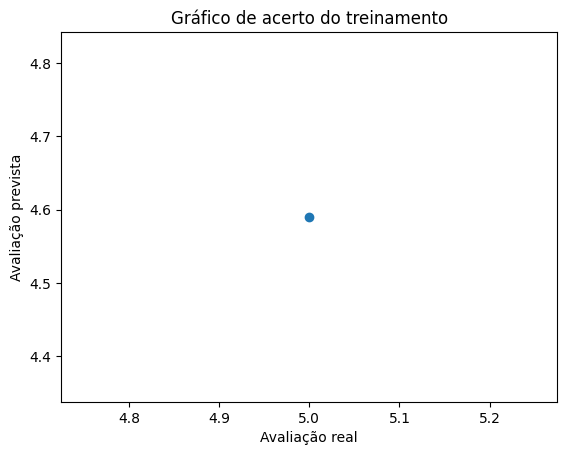

In [121]:
plt.scatter(y_test, y_pred)
plt.xlabel('Avaliação real')
plt.ylabel('Avaliação prevista')
plt.title('Gráfico de acerto do treinamento')
plt.show()



In [124]:
# Calculando a acurácia do modelo
acuracia = rf.score(X_test, y_test)
print(f'Acurácia do modelo: {acuracia:.2f}')



Acurácia do modelo: nan


c:\Users\jesie\OneDrive\Documentos\jesiel\projeto original\projeto_flask_colaborativo\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [130]:
def recomendar_filme(tipo, ano_lancamento, classificacao, nota_minima):
    # Recomendando filmes com base na nota prevista
    filme = pd.DataFrame({'Tipo de Conteúdo': [tipo], 'Ano de Lançamento': [ano_lancamento], 'Classificação': [classificacao]})
    nota_prevista = rf.predict(filme)[0]
    filmes_similares = df[(df['Avaliação'] >= nota_minima) & (abs(df['Avaliação'] - nota_prevista) <= 1)]
    return filmes_similares

tipo = 0
ano_lancamento = 2020
classificacao = 2
nota_minima = 4
filmes_recomendados = recomendar_filme(tipo, ano_lancamento, classificacao, nota_minima)



In [131]:
print("Filmes Recomendados:")
for index, filme in filmes_recomendados.iterrows():
    print(f"Título: {filme['Título']}")
    print(f"Avaliação: {filme['Avaliação']}")
    print(f"Ano de Lançamento: {filme['Ano de Lançamento']}")
    print("------------------------")

Filmes Recomendados:
Título: Norm of the North: King Sized Adventure
Avaliação: 4
Ano de Lançamento: 2019
------------------------
Título: Jandino: Whatever it Takes
Avaliação: 5
Ano de Lançamento: 2016
------------------------
Título: Transformers: Robots in Disguise
Avaliação: 4
Ano de Lançamento: 2016
------------------------
Título: #realityhigh
Avaliação: 5
Ano de Lançamento: 2017
------------------------
